# **Scalable Diffusion with Transformers (DiT)  |  A Few Experiments**


    Sharif University of Technology   |  TGML Lab
    Presenters:  Maryam Rezaee & Mahshid Dehghani

<br/>

---

## **Introduction**

In this notebook, we aim to experiment with the pre-trained **DiT (Diffusion Transformers)** model from the paper *Scalable Diffusion Models with Transformers*. The paper introduces a transformer-based approach to diffusion models, demonstrating strong generative performance (with state-of-the-art results).

The official GitHub repository provides all model codes used in the paper's experiments as well as the pre-trained weights of the largest and best model, **DiT-XL/2**, trained for **256×256** and **512×512** images. Since training a model of this scale from scratch is computationally expensive, we will use the available pre-trained weights to explore how the model behaves under different hyperparameters during inference. The goal is to better understand its performance, interpret the results, and analyze how various settings influence the generated outputs.  

<br/>

---

## **Setup**

### **Environment Setup**

First, we clone the official **DiT** repository from GitHub, giving us access to the model code, inference scripts, and pre-trained weights.

In [ ]:
# Cloning DiT Repo

!git clone https://github.com/facebookresearch/DiT.git

Cloning into 'DiT'...
remote: Enumerating objects: 102, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 102 (delta 57), reused 35 (delta 35), pack-reused 20 (from 1)
Receiving objects: 100% (102/102), 6.36 MiB | 32.91 MiB/s, done.
Resolving deltas: 100% (57/57), done.


Then, we navigate into the cloned `DiT` directory and set the **PYTHONPATH** environment variable. This ensures that Python can correctly locate and import the DiT modules when we run our scripts.  

In [ ]:
# Setting Environment

import os
os.chdir('DiT')
os.environ['PYTHONPATH'] = '/env/python:/content/DiT'

Additionally, we need to install or upgrade the necessary Python packages:  
- **diffusers** – Provides utilities for working with diffusion models.  
- **timm** – A library for pre-trained models and utilities, used internally by DiT.

In [ ]:
# Installing Packages

!pip install diffusers timm --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 51.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

And finally, we import all necessary modules, including those from the repository.

- **`torch`** – PyTorch for handling tensors and model inference.  
- **`torchvision.utils.save_image`** – Saves generated images.  
- **`DiT`** – Imports the core directory.  
- **`diffusion.create_diffusion`** – A helper function to set up the diffusion process.  
- **`diffusers.models.AutoencoderKL`** – A VAE-based autoencoder used for latent space image generation.  
- **`download.find_model`** – Helps locate and load pre-trained weights.  
- **`models.DiT_XL_2`** – The largest pre-trained DiT model.  
- **`PIL, IPython.display, matplotlib`** – Used for displaying generated images.  
- **`torch.set_grad_enabled(False)`** – Disables gradient tracking to reduce memory usage since we are only running inference.  
- **`device = "cuda" if torch.cuda.is_available() else "cpu"`** – Automatically selects GPU (if available) for faster inference.  

In [ ]:
# Importing Packages

import torch
from torchvision.utils import save_image

import DiT
from diffusion import create_diffusion
from diffusers.models import AutoencoderKL
from download import find_model
from models import DiT_XL_2

import numpy as np
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"

### **Model Preparation**

The **DiT** GitHub repository contains several key files:

- **`diffusion folder`** – Implements the diffusion process, including sampling and noise scheduling. The code is modified from OpenAI's diffusion repos.
- **`models.py`** – Defines the architecture of different DiT variants, including **DiT-XL/2**.  
- **`download.py`** – Handles downloading and locating pre-trained model weights.  
- **`train.py`** – A minimal training script for DiT using PyTorch DDP.
- **`sample.py, sample_ddp.py`** – Helpers for sampling from the DiT.

Using these files, we will load the **DiT-XL/2** model and a **VAE** to encode/decode images in a latent space.

In [ ]:
# Loading Model

def load_model(image_size, latent_size, vae_model_name):

    # initializing pre-trained DiT model
    dit_model = DiT_XL_2(input_size=latent_size).to(device)

    # loading pre-trained DiT weights
    state_dict = find_model(f"DiT-XL-2-{image_size}x{image_size}.pt")
    dit_model.load_state_dict(state_dict)
    dit_model.eval()

    # loading pre-trained VAE model
    vae = AutoencoderKL.from_pretrained(vae_model_name).to(device)

    return dit_model, vae

This function:  
- Loads the **DiT-XL/2** model and moves it to the appropriate device (CPU/GPU).  
- Retrieves the **pre-trained weights** for the specified image resolution.  
- Loads a **VAE** from Stability AI for encoding/decoding images in latent space to facilitate Latent Diffusion in the VAE's latent space for a less costly implementation of DiT.  

Following this, we will define the initial hyperparameters for loading the model:

- We use **256×256** images for **faster inference**.  
- The **latent space size** is **image_size / 8** (32×32 for 256×256 images) per the paper.
- The **VAE model** is chosen from Stability AI due to good performance and availability.  
- The **sampling steps** define how many diffusion steps we run (higher values improve quality but slow inference, we will be experimenting with this later on).

In [ ]:
# Defining Global Hyperparamters

image_size = 256                                # {256, 512}
latent_size = image_size // 8                   # the pretrained DiT operates in an 8x downsampled latent space

vae_model_name = "stabilityai/sd-vae-ft-ema"    # pre-trained VAE for encoding/decoding
                                                # choices: {"stabilityai/sd-vae-ft-mse", "stabilityai/sd-vae-ft-ema"}

sampling_steps = 250                            # number of diffusion steps from (affects quality and speed)
                                                # options can be {0, ..., 1000}

Finally we will:

- **Load the pre-trained DiT model and VAE** using our function and hyperparameters.
- **Initialize the diffusion process** with the selected number of sampling steps using the aforementioned altered diffusion from OpenAI from the DiT repo.

In [ ]:
# Running Model Creation

dit_model, vae = load_model(image_size, latent_size, vae_model_name)
diffusion = create_diffusion(str(sampling_steps))

100%|██████████| 2.70G/2.70G [01:06<00:00, 40.8MB/s]
/content/DiT/download.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(local_path, map_location=l

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

### **Inference Setup**

We now define our **latent noise (z)** and **class labels**, which will be used for all experiments.  

In [ ]:
# Setting Up Inference

# defining class label 87: parrot
class_label = 87

# sampling latent noise for the class
# setting first var as 2 since DiT uses paired setup for "cond" and "uncond"
z = torch.randn(2, 4, latent_size, latent_size, device=device)

# converting class label to tensor
# 1000 is the "null" or "uncond" class for CFG
y = torch.tensor([class_label, 1000], device=device)

In the above code:

- The **class label** specifies the categories of images we want to generate (ImageNet labels); multiple classes can be given for sample variety but for consistency of visual experiments, we will choose only one class for now.  
- `z` is a **random latent tensor** that will be progressively denoised into meaningful images. This same **z** will be used across all experiments.
- `y` holds the **class labels**, which guide the model during inference. We must note that DiT uses a paired setup for conditional and unconditional cases as explained below, therefore the null class 1000 is given as the second part of the pair.


Now, we must remember **Classifier-Free Guidance (CFG)**, which is commonly used in **Conditional Diffusion Models**, including **DiT**. CFG helps guide the model toward a desired class label without requiring an external classifier.  

In CFG, two forward passes are performed:  
1. **Unconditional Prediction**: The model generates an output without any class conditioning.  
2. **Conditional Prediction**: The model generates an output with the class conditioning.  

The final output is computed as:  

$$\hat{\epsilon}(x_t, y) = \epsilon_{\text{uncond}}(x_t) + s \cdot (\epsilon_{\text{cond}}(x_t, y) - \epsilon_{\text{uncond}}(x_t))$$

where:  
- $\hat{\epsilon}(x_t, y)$ is the final noise estimate used for denoising.  
- $\epsilon_{\text{uncond}}(x_t)$ is the **unconditional** noise estimate.  
- $\epsilon_{\text{cond}}(x_t, y)$ is the **class-conditioned** noise estimate.  
- $s$ (the `classifier_free_guidance_scale`) controls how much we amplify the difference between the conditioned and unconditioned estimates.  

A higher $s$ increases adherence to the class label but may reduce diversity. Based on this, we must define $s$ when performing sampling. In the paper, they choose $s = 4$. Later on, we will explore the visual effects of different choices for $s$.  

In [ ]:
# Simple Sampling

# classsifier-free guidance scale to control the influence of class labels
classifier_free_guidance_scale = 4

# model keyword arguments using the scale and labels
dit_model_kwargs = dict(y=y, cfg_scale=classifier_free_guidance_scale)

# generating images using the preloaded diffusion model
# accessed from the `diffusion folder`, `gaussian_diffusion.py` file
samples = diffusion.p_sample_loop(
    model = dit_model.forward_with_cfg,
    shape = z.shape,
    noise = z,
    clip_denoised = False,
    model_kwargs = dit_model_kwargs,
    progress = True,
    device = device
)

# removing null class samples
samples, _ = samples.chunk(2, dim=0)

# decoding the latent samples into images
samples = vae.decode(samples / 0.18215).sample

  0%|          | 0/250 [00:00<?, ?it/s]

Therefore in the above code the below parts are implemented.

- **Classifier-Free Guidance Scale**:  
  - $s = 0$ → Unconditional generation (ignores class labels).
  - $s = 1$ → No guidance (samples from classes as learned)
  - $s = 10$ → Strongly adheres to class labels.  
  - The paper recommends **$s = 4$ as a balanced choice**. Later, we will explore why.
- **`p_sample_loop`**: Iteratively refines noise $z$ into an image in the Gaussian diffusion process.  
- **Removing null class samples**: Since CFG uses two versions of each sample (conditional/unconditional), we only keep the conditional samples.  
- **VAE Decoding**: The model generates images in a compressed latent space, so we decode them to the original resolution.  

Finally, we will:

- Save the generated image as a PNG file in the current directory.  
- Display the output image directly in the notebook.

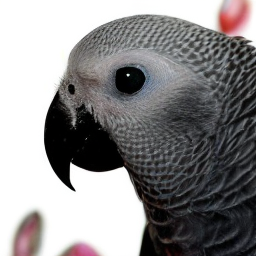

In [ ]:
# Saving and Displaying the Simple Sample

save_image(samples, "sample_simple.png", normalize=True, value_range=(-1, 1))
display(Image.open("sample_simple.png"))

## **Experiments**

### **Sampling Step Counts**

The number of **sampling steps** in the diffusion process determines how gradually the model refines the noisy input into a coherent image. Therefore, we hypothesize that:

- **Higher sampling steps (e.g., 250)** → More gradual denoising, better detail, but longer inference time.  
- **Lower sampling steps (e.g., 10)** → Faster inference but potentially lower-quality results with more artifacts.  

Here, we test the effect of reducing the sampling steps to 10 and compare it to our earlier results using 250 steps.  

In [ ]:
# Setting a New Sampling Step Value

new_sampling_steps = 10
diffusion_10_steps = create_diffusion(str(new_sampling_steps))

- We set `new_sampling_steps = 10`, to now test how well the model performs with fewer steps.  
- We create a new diffusion process with `create_diffusion()`, which adjusts the noise schedule accordingly.  

In [ ]:
# Generating Images with 10 Steps

# generating images using the preloaded diffusion model
samples_10_steps = diffusion_10_steps.p_sample_loop(
    model = dit_model.forward_with_cfg,
    shape = z.shape,
    noise = z,
    clip_denoised = False,
    model_kwargs = dit_model_kwargs,
    progress = True,
    device = device
)

# removing null class samples
samples_10_steps, _ = samples_10_steps.chunk(2, dim=0)

# decoding the latent samples into images
samples_10_steps = vae.decode(samples_10_steps / 0.18215).sample

  0%|          | 0/10 [00:00<?, ?it/s]

- We perform **faster inference** using only 10 diffusion steps.
- The `p_sample_loop()` function runs the **denoising process** for the given number of steps.  
- Since **CFG generates both unconditional and conditional samples**, we use `chunk(2, dim=0)` to remove the unconditional ones. This is because, in CFG, for every conditional sample (guided by the class label), there is a corresponding unconditional sample (class label ignored); the model outputs both in a batch of size `2 × batch_size`, where the first half is the class-conditioned samples and the second half is the unconditional (null-class) samples. Therefore, We keep only the first half (the class-conditioned samples) and discard the unconditional half (_).
- Finally, the **VAE decodes** the latents into full-resolution images. We divide by `0.18215` as this is the scaling factor used in latent space for the VAE; without dividing by this, the VAE might produce incorrect brightness/contrast levels in the final image.

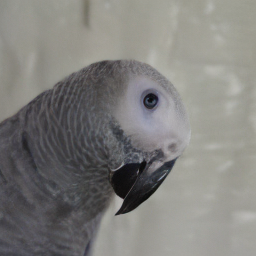

In [ ]:
# Saving and Displaying the Generated Image

save_image(samples_10_steps, "sample_10_step.png", nrow=4, normalize=True, value_range=(-1, 1))
display(Image.open("sample_10_step.png"))

From the result, we observe:  

- **Faster inference** - due to fewer steps, less time is needed to produce one imgae (going from 40 seconds for one sample to 1 second).  
- **Lower image quality** – some details appear blurry or noisy compared to 250 steps.  
- **Incomplete structures** – the model has less time to fully refine the image and the image seemes badly formed.  

This confirms our hypothesis that **reducing sampling steps leads to faster but lower-quality results**. Later, we will explore how different guidance scales interact with sampling steps to balance speed and quality.

<br/>

---

### **Class Labels**

In the ImageNet dataset (which the given DiT is trained on), class labels range from **0 to 999**, each corresponding to a specific object category. For example:  
- **0–99**: Animals (e.g., dog breeds, birds, fish)  
- **100–299**: Objects (e.g., vehicles, tools, furniture)  
- **300–599**: Electronic devices & instruments (e.g., computers, musical instruments)  
- **600–999**: Clothing, food, scenery, abstract concepts

Since our current samples use label **87 (parrot)**, we will now generate an image from a different category. Specifically, we will use **class 481**, which corresponds to "cassette player" or similar audio devices.

This will help us verify that the model correctly follows the provided label and that our conditional generation is working as expected.  

In [ ]:
# Defining New Class Label

new_class_label = 481                                             # for cassette, cassette player, CD player
new_y = torch.tensor([new_class_label, 1000], device=device)      # 1000 is the unconditional class

- We set `new_class_label = 481` to generate an image of a **cassette player**.  
- As before, the second label, `1000`, is used for **CFG** as the "unconditional" class.  
- This ensures that the model applies guidance when generating the sample.

In [ ]:
# Generating an Image for the New Class

# setting up model parameters for the new class
cassette_dit_model_kwargs = dict(y=new_y, cfg_scale=classifier_free_guidance_scale)

# generating the sample using the diffusion process
cassette_samples = diffusion.p_sample_loop(
    model = dit_model.forward_with_cfg,
    shape = z.shape,
    noise = z,
    clip_denoised = False,
    model_kwargs = cassette_dit_model_kwargs,
    progress = True,
    device = device
)

# removing null class samples
cassette_samples, _ = cassette_samples.chunk(2, dim=0)

# decoding the latent samples into images
cassette_samples = vae.decode(cassette_samples / 0.18215).sample

  0%|          | 0/250 [00:00<?, ?it/s]

- We create `cassette_dit_model_kwargs`, passing `new_y` and `cfg_scale`.  
- The model **samples an image** from the new class using the DiT model and diffusion process.  
- We split the samples using `.chunk(2, dim=0)` to **remove the unconditional** ones.  
- The VAE decodes the image, converting it from latent space to pixel space.

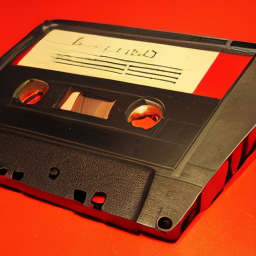

In [ ]:
# Saving and Displaying the New Class Sample

save_image(cassette_samples, "sample_newclass.png", normalize=True, value_range=(-1, 1))
display(Image.open("sample_newclass.png"))

As we can see, the image saved as `"sample_newclass.png"` is indeed the intended **cassette player** and was generated correctly. With this small experiment, we can now move on to test random generation from various labels using our model.

<br/>

---

### **Sampling Diversity**

In this section, we explore the **diversity and quality** of samples generated by our diffusion model across different class labels.  
- Instead of focusing on a single class, we **randomly sample different class labels** from the dataset.
- This allows us to see how well the model generalizes across various object categories.  
- By generating **20 images** from **20 different classes**, we gain insight into how distinct and realistic the samples are.

In [ ]:
# Generating Diverse Samples

import random

num_images = 20                                                # number of samples to generate
for i in range(num_images):

    class_label_i = random.randint(0, 999)                     # randomly selecting a class from 0 to 999 (excluding null class 1000)
    y_i = torch.tensor([class_label_i, 1000], device=device)
    dit_model_kwargs_i = dict(y=y_i, cfg_scale=classifier_free_guidance_scale)

    # generate sample using the diffusion process
    samples_i = diffusion.p_sample_loop(dit_model.forward_with_cfg, z.shape, z, clip_denoised=False, model_kwargs=dit_model_kwargs_i, progress=True, device=device)
    # removing null classes and decoding
    samples_i, _ = samples_i.chunk(2, dim=0)
    samples_i = vae.decode(samples_i / 0.18215).sample

    # saving generated image
    save_image(samples_i, f"sample_{i}.png", nrow=4, normalize=True, value_range=(-1, 1))

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

...

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

- We randomly pick a class label between **0 and 999** (due the base ImageNet dataset) to ensures we sample from a variety of objects.
- Like before, we run the **diffusion model with Classifier-Free Guidance** to generate each sample; the `p_sample_loop` function iteratively denoises from a random latent noise to produce a meaningful image.  
- We remove the **unconditional (null-class) samples**, keeping only the class-conditioned outputs.  
- The samples are scaled back and passed through the **VAE decoder** to obtain final images, which are saved as `sample_0.png`, `sample_1.png`, etc. using the premade `save_image` from `torchvision`.

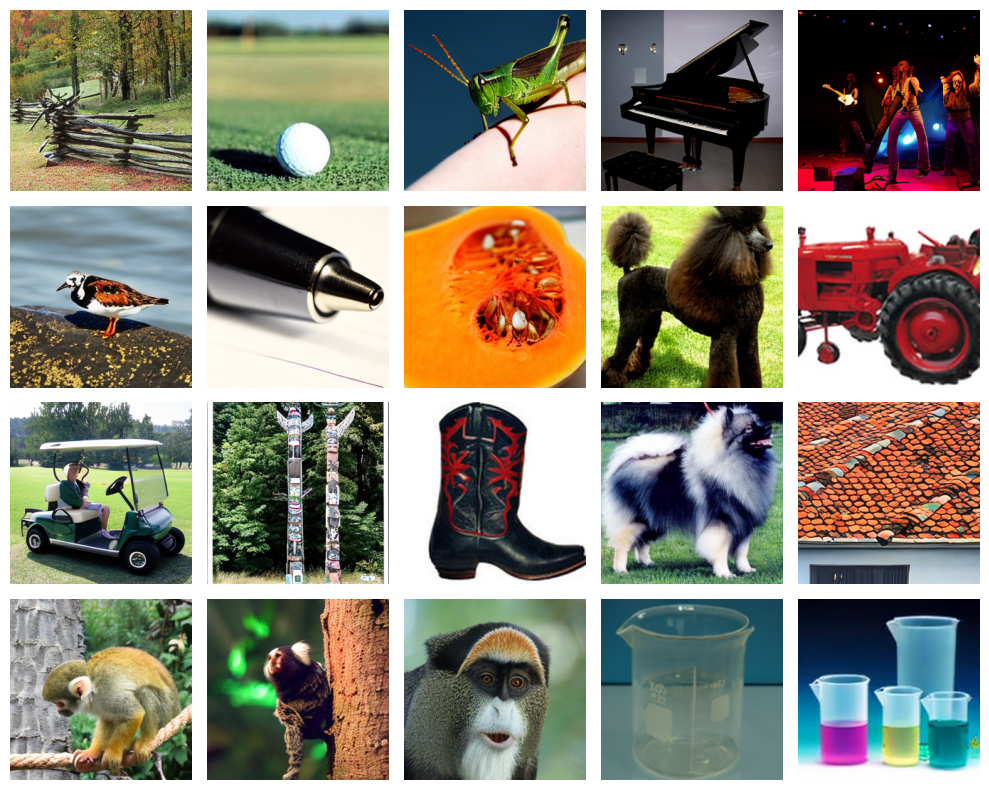

In [ ]:
# Displaying the Samples

fig, axes = plt.subplots(4, 5, figsize=(10, 8))
axes = axes.ravel()

for i in range(20):
    img = mpimg.imread(f"sample_{i}.png")
    axes[i].imshow(img)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

This experiment allows us to **assess sample diversity** by generating images from **different random classes**. We can visually compare how different objects are represented and see the **coherence and realism** of the outputs.

<br/>

---

### **Classifier-Free Guidance**

In our previous discussion on **Classifier-Free Guidance (CFG)**, we explained that the guidance scale $s$ controls how much the model emphasizes the conditional information (class labels in our case) during sampling.  

The simplified **CFG formula** is:  

$$\epsilon_{\text{guided}} = \epsilon_{\text{unconditional}} + s \cdot (\epsilon_{\text{conditional}} - \epsilon_{\text{unconditional}})$$

Due to the above formula, we claimed that:  

- $s = 0$ → No class guidance, fully unconditional generation from the learned general distribution.  
- $s = 1$ → Minimal class guidance, following $c$ exactly as it was trained.  
- $s = 4$ → The value recommended in the DiT paper, balancing quality and diversity.  
- $s = 10$ → Strongest class guidance, but may lead to over-exaggerated features or artifacts.  

To observe the visual impact of CFG, we generate **20 images** for each $s$ value **$(0, 1, 4, 10)$** and visualize the differences.

In [ ]:
# Helper Function for Generating and Displaying Samples

def generate_and_display(cfg_scale, num_images=20):

    # defining model kwargs with the given CFG scale
    dit_model_kwargs = dict(y=y, cfg_scale=cfg_scale)

    # generating and saving images
    for i in range(num_images):
        samples_i = diffusion.p_sample_loop(
            model = dit_model.forward_with_cfg,
            shape = z.shape,
            noise = z,
            clip_denoised = False,
            model_kwargs = dit_model_kwargs,
            progress = True,
            device = device
        )
        samples_i, _ = samples_i.chunk(2, dim=0)
        samples_i = vae.decode(samples_i / 0.18215).sample
        save_image(samples_i, f"sample_cfg{cfg_scale}_{i}.png", normalize=True, value_range=(-1, 1))

    # plotting the generated images
    fig, axes = plt.subplots(4, -(-num_images//4), figsize=(10, 8))
    axes = axes.ravel()

    for i in range(num_images):
        img = mpimg.imread(f"sample_cfg{cfg_scale}_{i}.png")
        axes[i].imshow(img)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

To make our code cleaner and avoid redundancy, we define a helper function that:  

1. Runs the sampling process for a given $s$.  
2. Saves 20 generated images.  
3. Displays them in a 4×5 grid.

Now, we can run the function `generate_and_display()` for our four values of $s$ and compare the mathematical effects with the visual ones.

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

...

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

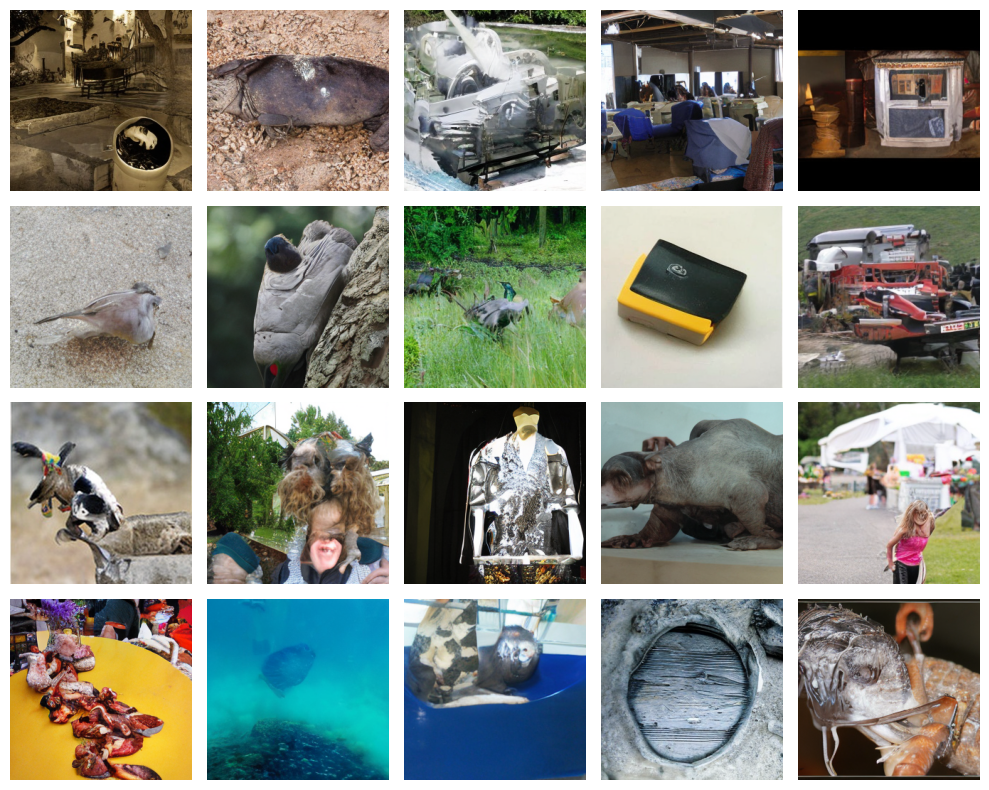

In [ ]:
# Running CFG = 0

generate_and_display(cfg_scale=0)

If $s=0$, the simplified **CFG formula** becomes:  

$$\epsilon_{\text{guided}} = \epsilon_{\text{unconditional}}$$

This implies that:

- The model **ignores class label** and generates an image as if no class was given.
- It samples from the **general distribution of images it has learned** rather than focusing on a specific category.
- Since **DiT was trained with class conditioning**, the results of this variant will be diverse but likely fail as well-formed images; this is supported by the generated images, most of which are incoherent.

If one wants diversity, training a model without class conditioning (for no classes) or inferring with a small $s$ from a conditional model (for example, $s=0.5$ for conditioned diversity) is a better alternative for reaching sensible images. With conditionally trained diffusions, however, setting $s=0$ is meaningless as we observed above; this is why the repo's own sampling code asserts `s >= 1.0`.

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

...

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

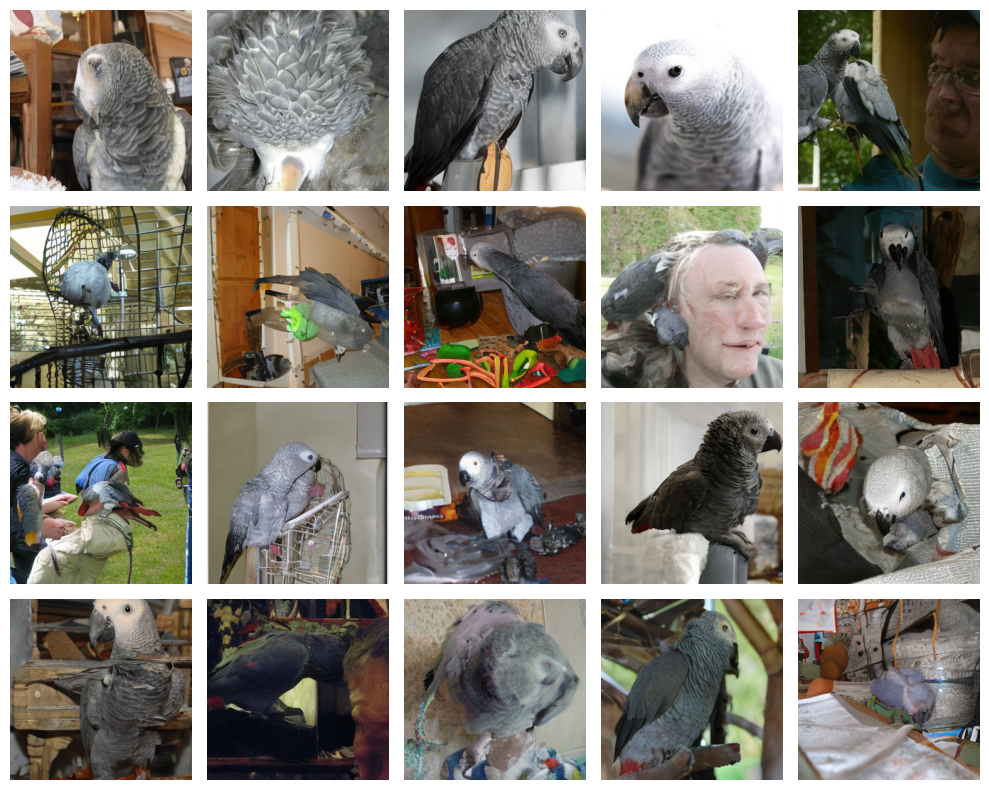

In [ ]:
# Running CFG = 1

generate_and_display(cfg_scale=1)

If $s=1$, the simplified **CFG formula** becomes:  

$$\epsilon_{\text{guided}} = \epsilon_{\text{conditional}}$$

This implies that:

- The formula reduces to **just conditional prediction**.
- The model follows $c$ **exactly as it was trained**, without exaggeration.
- There is **no additional emphasis on $c$**, just whatever the model naturally learned about the class. This results in some control over what class to include in the image, but ambiguities and messy images will persist, as seen in the generated samples above.

In other words, the model is not artificially increasing the influence of $c$; sampling is still conditioned, but there is no guidance towards increasing focus on some class to make that class the core of the generated image, resulting in better focus compared to previous variant, but more diverse images compared to the next variants.

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

...

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

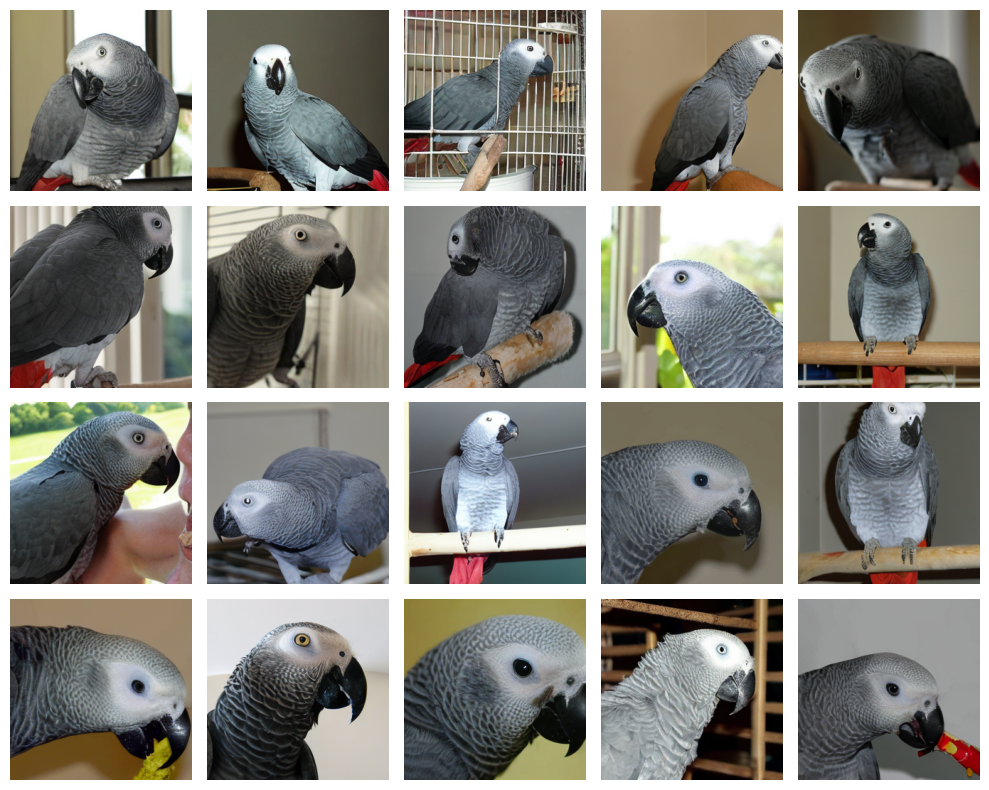

In [ ]:
# Running CFG = 4

generate_and_display(cfg_scale=4)

If $s=4$, the simplified **CFG formula** becomes:  

$$\epsilon_{\text{guided}} = 4 \cdot \epsilon_{\text{conditional}} - 3 \cdot \epsilon_{\text{unconditional}}$$

This implies that:

- The difference $(\epsilon_{\text{conditional}} - \epsilon_{\text{unconditional}})$ is **amplified by $s$**, pushing the final prediction further towards the conditional direction.
- The model increases its focus on $c$, making the generation **more strongly conditioned**.
- Following $c$ more strictly causes the results to be **sharper, better defined around the intended class, with less diversity**. This can be seen in the above grid compared to previous generations.

It should be noted that $s$ is still not too large, therefore the samples still contain other details. This balance of fidelity and diversity is why the DiT paper uses $s=4$ by default.


  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

...

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

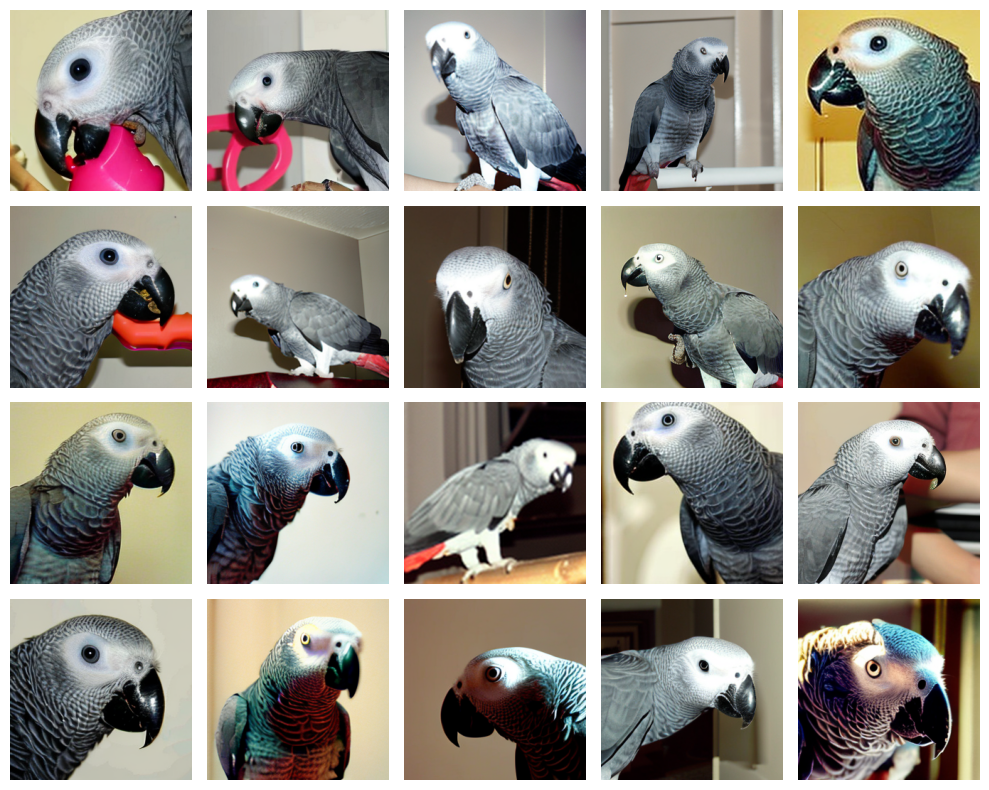

In [ ]:
# Running CFG = 10

generate_and_display(cfg_scale=10)

If $s=10$, the simplified **CFG formula** becomes:  

$$\epsilon_{\text{guided}} = 10 \cdot \epsilon_{\text{conditional}} - 9 \cdot \epsilon_{\text{unconditional}}$$

This implies that:

- Like before, the final prediction is pushed even further towards the conditional direction.
- The model increases its focus on $c$ to the maximum, making the generation **mostly focused on the condition**.
- This further increases sharpness and fidelity as seen above, while almost removing all further realistic details around the intended class object.

The $s$ in this variant is the largest $s$ listed by the paper and shows exactly how producing almost only single objects of one class can be possible (though perhaps in an overly sharpened state).

<br/>

---


### **Noise Interpolation**

To gain an insight into the smoothness of the learned latent space and the model’s “morphing” ability, we will also run an experiment to **interpolate between two independent noise samples** and observe how the model smoothly transitions between them.

Basically, rather than generating a single image from a random noise vector, we:  
1. **Sample two independent random noise vectors** (`z1` and `z2`).  
2. **Interpolate between them** by creating intermediate noise vectors.  
3. **Run the diffusion model on each interpolated noise vector** to generate images.  
4. **Display the sequence** to visualize the morphing effect.

This will provide insight into whether the model's learned latent space is **smooth and meaningful**, or if it produces abrupt and unnatural transitions.

In [ ]:
# Defining Noise Vectors for Interpolation

z1 = torch.randn_like(z)          # first random noise sample
z2 = torch.randn_like(z)          # second random noise sample

- We **sample two independent noise vectors** (`z1` and `z2`) from a standard normal distribution, similar to the `z` used across all previous experiments.  
- These will serve as the **start** and **end points** for our interpolation.  

In [ ]:
# Interpolating Between Noise Vectors

def interpolate_noise(z1, z2, num_steps=10):

    alphas = np.linspace(0, 1, num_steps)                                       # interpolation weights
    interpolated_z = [(1 - alpha) * z1 + alpha * z2 for alpha in alphas]

    return interpolated_z

num_interpolation_steps = 10
interpolated_z_vectors = interpolate_noise(z1, z2, num_interpolation_steps)

The helper function above helps us generate interpolated noise vectors between two noise samples.
- We generate **10 interpolated noise vectors** by linearly blending `z1` and `z2` using different weights (`alpha`).  
- `alpha = 0` corresponds to `z1`, and `alpha = 1` corresponds to `z2`.  
- Intermediate values smoothly transition from `z1` to `z2`, creating a gradual morphing effect.  

For consistency, we keep the previous `class label` and `y` from our solo expermints. The code included:

```
class_label = 87
y = torch.tensor([class_label, 1000], device=device)
```

In [ ]:
dit_model_kwargs = dict(y=y, cfg_scale=classifier_free_guidance_scale)
generated_images = []

for i, z_interp in enumerate(interpolated_z_vectors):
    # running diffusion on each interpolated noise vector
    sample = diffusion.p_sample_loop(
        model = dit_model.forward_with_cfg,
        shape = z.shape,
        noise = z_interp,
        clip_denoised = False,
        model_kwargs = dit_model_kwargs,
        progress = True,
        device=device
    )

    # removing null class samples
    sample, _ = sample.chunk(2, dim=0)

    # decode latent sample into image
    sample = vae.decode(sample / 0.18215).sample

    # save image for visualization
    save_image(sample, f"sample_interpolated_{i}.png", normalize=True, value_range=(-1, 1))

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

- We **loop through each interpolated noise vector** and run it through the diffusion model.  
- The process is identical to standard sampling, except that we use the **interpolated noise** instead of pure random noise.
- The output samples are saved as in `sample_interpolated_0.png, etc.` for visualization.  

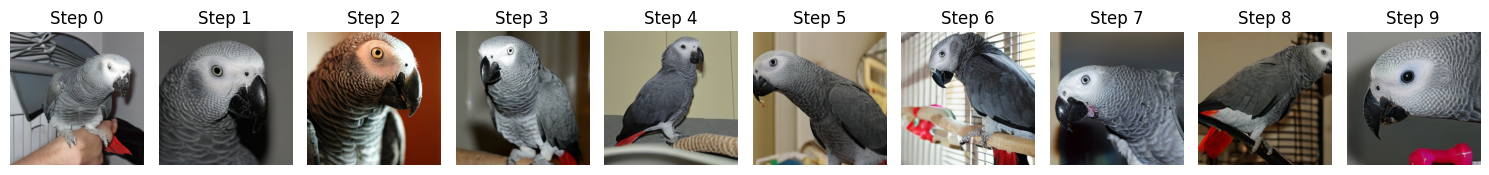

In [ ]:
fig, axes = plt.subplots(1, num_interpolation_steps, figsize=(15, 3))

for i in range(num_interpolation_steps):
    img = mpimg.imread(f"sample_interpolated_{i}.png")
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Step {i}")

plt.tight_layout()
plt.show()

We plot all interpolated images in a row to visualize the smooth transition. This allows us to see how the model **morphs between two generated images**. As we can see, the model has learned a mostly **continuous latent space**, because the transition appears natural without sudden jumps.  

#### **Observations**
- **Mostly Smooth Interpolation:** The model seems to have a mostly well-structured latent space, as the generated images gradually transform in a meaningful way (except for in steps 4 and 8) with the parrot turning to face the left from the right. Addtionally, there are **no artifacts**, indicating a well-defined space.
- **Some Clear Discontinuities:** The model struggles in two places to capture the direction shift (**abrupt changes** are visible), and there is no meaningful relationshoips between any other aspects of the image.
- **Class-Specific Effects:** Some objects (the direction of the parrot's face, its color, and wing positioning) morph more smoothly than others (the parrot's head tilt), indicating the model has learned the class structure in a specific way.  


<br/>

---

### **Further Experiment Ideas**

Beyond these experiments, we can conduct more structured experiments to analyze different aspects of the model’s performance, generalization, and latent space structure.

#### **1. FID Analysis Across Different CFG Scales**  
- **Goal:** Measure the impact of the classifier-free guidance (CFG) scale (`s`) on image quality and diversity.  
- **Method:**  
  1. Generate a **large number of images** for each `s` value from `0` to `10`.  
  2. Calculate **Fréchet Inception Distance (FID)** between the generated images and the original dataset.  
  3. Compare the **11 FID scores** (one for each `s`).  
- **Expected Insight:**  
  - Lower `s` values promote **more diverse** but potentially **lower quality** samples.  
  - Higher `s` values should yield **sharper**, more **realistic images**, but may sacrifice **diversity**.  

#### **2. Class-Wise FID and Diversity Analysis**  
- **Goal:** Investigate how well the model learns specific object categories.  
- **Method:**  
  1. Generate samples for **each class separately** (e.g., all 1,000 classes).  
  2. Compute **FID scores per class** to assess generation quality for each category.  
  3. Measure **intra-class diversity** by computing LPIPS (Learned Perceptual Image Patch Similarity) scores among images of the same class.  
- **Expected Insight:**  
  - Some classes may have **lower FID**, meaning they are easier to generate.  
  - Other classes might suffer from **mode collapse** (low diversity) or **high FID** (poor quality).  

#### **3. Latent Space Traversal for Individual Features**  
- **Goal:** Identify meaningful latent directions that correspond to semantic changes (e.g., object rotation, lighting, size).  
- **Method:**  
  1. Generate an image from a fixed noise vector.  
  2. Apply **small perturbations** along different latent dimensions.  
  3. Observe which latent dimensions correspond to meaningful changes.  
- **Expected Insight:**  
  - Some latent directions might control **pose, lighting, or texture**, revealing disentangled representations.  
  - If latent space is highly entangled, small changes in `z` might produce unpredictable shifts in object appearance.  

#### **4. Class Mixing via Conditional Interpolation**  
- **Goal:** Generate hybrid images by interpolating between two **different class labels** instead of noise vectors.  
- **Method:**  
  1. Generate two images, each with a different class label (`y1` and `y2`).  
  2. Interpolate between their one-hot class embeddings rather than their noise vectors.  
  3. Observe whether the model generates meaningful hybrids.  
- **Expected Insight:**  
  - Some object pairs might **blend smoothly** (e.g., a lion and a tiger).  
  - Others might **fail catastrophically**, indicating a lack of compositional generalization.  

#### **5. Cross-Class Analogies in Latent Space**  
- **Goal:** Discover meaningful latent transformations using vector arithmetic (e.g., **"dog" + "stripes" = "zebra"**).  
- **Method:**  
  1. Compute the latent vector difference between a **base class** (e.g., "horse") and a **modified version** (e.g., "zebra").  
  2. Apply this difference to a different class (e.g., "dog") and observe the transformation.  
  3. Check if the transformation generalizes well across multiple samples.  
- **Expected Insight:**  
  - If the model has a **well-structured latent space**, certain transformations should be **consistent and meaningful**.  
  - If latent representations are entangled, the transformations might not generalize well.  

#### **6. Zero-Shot Generation with Unseen Class Labels**  
- **Goal:** Investigate whether the model can generalize to **unseen classes** by assigning arbitrary class indices.  
- **Method:**  
  1. Generate samples using class labels **beyond the training range** (e.g., `y=1001, 1100, 1500`).  
  2. Observe whether the model produces meaningful images or degenerates into random noise.  
- **Expected Insight:**  
  - If the model **relies purely on class conditioning**, it should fail for unknown labels.  
  - If it has **learned a more general representation**, it might still generate meaningful images by interpolating existing concepts.  

#### **7. Fine-Tuning on a New Dataset and Evaluating Adaptation**  
- **Goal:** Adapt the pre-trained model to a **new domain** (e.g., anime faces, medical scans) and measure how well it transfers knowledge.  
- **Method:**  
  1. Fine-tune the diffusion model on a **small dataset** of a different domain.  
  2. Evaluate how quickly it **adapts** without losing prior knowledge.  
  3. Compare fine-tuned vs. base model samples.  
- **Expected Insight:**  
  - If the model **adapts quickly**, it has strong **transfer learning capabilities**.  
  - If it **catastrophically forgets** previous knowledge, fine-tuning strategies may need to be adjusted.  

#### **8. Class-Specific Interpolation Analysis**  
- **Goal:** Identify if certain class pairs interpolate more smoothly than others.  
- **Method:**  
  1. Select different **pairs of class labels** (e.g., "dog ↔ cat", "car ↔ airplane").  
  2. Perform latent space interpolation **between their noise vectors**.  
  3. Compare how **gradual and meaningful** the transitions appear.  
- **Expected Insight:**  
  - Some classes may **blend seamlessly** (e.g., similar objects), while others show **disjointed transformations**.  
  - This can reveal how well the model learns **class-specific features** versus more abstract representations.  

#### **9. Non-Linear Interpolation for Smoother Morphing**  
- **Goal:** Test if **spherical interpolation (slerp)** results in more natural transitions than simple linear interpolation.  
- **Method:**  
  1. Replace linear interpolation with **slerp**, which follows a geodesic in the latent space.  
  2. Compare the generated sequences to standard **linear interpolation**.  
- **Expected Insight:**  
  - Slerp may yield **smoother** and more **visually consistent** transitions, especially for high-dimensional latent spaces.  
  - If linear interpolation produces **abrupt changes**, it suggests that the latent space is **not well-structured** for simple blending.  

### **10. Effect of CFG Scale on Interpolation Smoothness**  
- **Goal:** Examine how the **Classifier-Free Guidance (CFG) scale** affects interpolation results.  
- **Method:**  
  1. Generate interpolation sequences with different **CFG values** (`s=0` to `s=10`).  
  2. Compare if increasing `s` **sharpens** images but **reduces continuity** in the transformation.  
- **Expected Insight:**  
  - Higher `s` may make intermediate samples **look more like one class or the other**, rather than blending smoothly.  
  - Lower `s` might allow for **more gradual transitions**, but with potential artifacts or blurriness.  


With these experiments, we can provide even deeper insights into the **capabilities and limitations** of the pretrained diffusion transformer model.  
